# Scientific Programming Lab - Erde und Mond
Lara Artmann, Viktoria Backhaus, Bekir Taha Gede, Sheila Kaiser, Darian Mark, Luke Munderich

In [1]:
#Bitte ausführen, damit alles Notwendige importiert wird
#Note: Bei Änderungen der zugrundeliegenden Python-Files muss Jupyter neugestartet werden
import scipro

In [2]:
%%html
<!--Bitte diese Cell mit Run ausführen, damit die Styles geladen werden-->
<!--Bei Änderungen des CSS muss das Notebook im Browser neu geladen werden-->
<link rel="stylesheet" href="./styles/sciprolab.css">

In diesem Jupyter-Notebook soll die Implementierung des Erde-Mond Systems in Python über Newtons Gravitationsgesetz umgesetzt werden. Es werden die dahinter liegenden physikalischen Prinzipien erläutert und die Vorgänge werden visualisiert. Zusätzlich soll ein weiterer Planet (Theia) das System stören. Theia soll dabei mit verschiedenen Geschwindigkeiten und aus verschiedenen Richtungen in das System gelangen.

## Überblick
![Bild](class_diagram.png)

## Body Klasse 

Die Klasse representiert einen Himmelskörper in Form einer runden Masse.
Sie bildet den Grundbaustein des Projektes.

### Mathematische Formeln hinter den Funktionen:

#### 1. Geometrische Distanzbestimmung 
   Der Abstand zwischen zwei Himmelskörpern im dreidimensionalen Raum wird mithilfe des euklidischen Abstands berechnet.
   <div class="definition">
      Euklidischer Abstand
$$
d = \|\vec{r}_2 - \vec{r}_1\| = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2 + (z_2 - z_1)^2}
$$
   </div>
   
#### 2. Positionsänderung 
   Es wird die neue Position $\vec{r}_{(t + \Delta t)}$ Schritt für Schritt aus der aktuellen Position $\vec{r}_{(t)}$ und der Geschwindigkeit $\vec{v}_{(t)}$ berechnet:
   <div class="definition">
      Berechnung der neuen Position
$$
       \vec{r}_{(t + \Delta t)} = \vec{r}_{(t)} + \vec{v}_{(t)} \cdot \Delta t
$$
   </div>
   
#### 3. Geschwindigkeitsänderung 
   Die Änderung der Geschwindigkeit resultiert aus der anliegenden Beschleunigung $\vec{a}$ [5]:
   <div class="definition">
      Berechnung der neuen Geschwindigkeit
$$
       \vec{v}_{(t + \Delta t)} = \vec{v}_{(t)} + \vec{a}_{(t)} \cdot \Delta t
$$
   </div>
   
#### 4. Impulsberechnung 
   Der mechanische Impuls $\vec{p}$ ist das Produkt aus Masse und Geschwindigkeitsvektor:  
   <div class="definition">
      Formel für den Impuls
$$
       \vec{p} = m \cdot \vec{v}
$$
   </div>
   


In [6]:
import numpy as np
import math

class Body:
    
    def __init__(self, name:str, position, velocity, radius:float, mass:float, color: str):
        self.name = name
        self.position = np.array(position, dtype=float) # Typkonvertierung um sicherzustellen, dass es immer NumPy-Arrays sind
        self.velocity = np.array(velocity, dtype=float)
        self.radius = radius
        self.diameter = 2*radius
        self.mass = mass
        self.color = color # Farbe des Körpers für die spätere Visualisierung
        
    def get_distance_to_body(self, other: 'Body') -> float:
        
        ab = other.position - self.position
        distance = np.linalg.norm(ab)
        
        return distance
    
    
    def update_position(self, timeStep: float):
        self.position = self.position + self.velocity * timeStep
        
    def update_velocity(self, acceleration: np.ndarray, timeStep: float):
        self.velocity = self.velocity + acceleration * timeStep
        
    def get_momentum(self)-> np.ndarray:
        return self.mass*self.velocity

## Simulations-Klasse

Die Klasse Simulation implementiert die Physik des Programms. Sie agiert als diskrete Physik-Engine, welche die zeitliche Evolution des Mehrkörper-Systems (N-Körper-Problem) auf Basis der klassischen Newtonschen Mechanik berechnet.  

Die Klasse erfüllt dabei folgende Kernaufgaben:
- Verwaltung des Systems: Sie registriert alle am System beteiligten Himmelskörper (Body-Objekte) und initialisiert Datenstrukturen für die Speicherung der Trajektorien.

- Numerische Integration: Da eine analytische Lösung für N>2 Körper nicht existiert (3 Körper Problem, nutzt die Engine ein numerisches Integrationsverfahren. Sie berechnet in jedem konfigurierbaren Zeitschritt ($\Delta t$) die aktuellen Beschleunigungen, Geschwindigkeiten und Positionen aller Körper und nimmt eine kurzzeitig gleichmäßig beschleunigte Bewegung an. Dabei wird das Euler-Cromer-Verfahren genutzt (erst neue Geschwindigkeit, dann mit der neuen Geschwindigkeit neue Position berechnen) [9].

- Gravitative Wechselwirkung: Über die Methode calculate_gravity wird paarweise der Gravitationsvektor nach Newtons Gravitationsgesetz ermittelt.  

- Kollisionsmanagement: In jedem Simulationsschritt wird geprüft, ob sich die physikalischen Radien zweier Körper überschneiden. Bei Kontakt wird eine 100% inelastische Kollision simuliert, bei der die Massen und Impulse addiert werden und ein neuer, volumenbasierter Radius berechnet wird.

- Historisierung: Für die anschließende Visualisierung trackt die Klasse alle vergangenen Positionen (history), sodass Flugbahnen und Animationen exakt rekonstruiert werden können.

<div class="definition"><h3>Das 3 Körper Problem</h3>
Das Dreikörperproblem beschreibt die mathematisch unlösbare Aufgabe, die chaotischen und langfristig unvorhersehbaren Bewegungen von drei sich gegenseitig anziehenden Himmelskörpern (wie Planeten oder Sternen) exakt zu berechnen [2]. Aufgrund dieser Tatsache wird das System auf eine numerische Berechnung zurückgreifen, die in einzelnen Zeitschritten Kräfte und Beschleunigungen einzeln und hintereinander berechnet.
</div>

<div class="satz"><h3>Newtons Gravitationsgesetz</h3>
Die Simulation soll mit Newtons Gravitationsgesetz implementiert werden [1]:

$$
\vec{F}_{ji} = -G \cdot \frac{m_i \cdot m_j}{\|\vec{r}_{ji}\|^2} \cdot \frac{\vec{r_{ji}}}{\|\vec{r}_{ji}\|}
$$

- $F_{ji}$ ist dabei die Kraft, die ein Körper $j$ auf einen Körper $i$ auswirkt.
- $m_i, m_j$ sind die Massen der beiden Körper und
- $\vec{r}_{ji}$ ist deren Abstand.
- $G$ ist die Gravitationskonstante mit $G\approx 6,67430\cdot 10^{-11}\frac{m^3}{kg\cdot s^2}$.
- Die wirkende Kraft ist negativ, da es sich um eine anziehende Kraft handelt.
- $\vec{F}_{ji} = -\vec{F}_{ij}$ da beide Körper eine betragsmäßig gleichgroße Kraft in entgegengesetzte Richtung aufeinander wirken (Wechselwirkungsgesetz).
- $\frac{\vec{r_{ji}}}{\|\vec{r}_{ji}\|}$ ist der Einheitsverktor des Richtungsvektors (Länge 1), um die Richtung des Kraftvektors anzupassen.
</div>

<div class="satz"><h3>Newtons Grundgleichung der Mechanik</h3>
$$
\vec{F} = m \cdot \vec{a}
$$
Wirkt auf einen Körper der Masse $m$ eine Kraft $\vec{F}$, so wird der Körper in die Richtung der Kraft beschleunigt [4]. Dieses Gesetz wird umgeformt verwendet, um die Kräfte, die aus dem Gravitationsgesetz resultieren in Beschleunigungne umzurechnen:
$$
    \vec a = \frac{\vec F}{m}
$$
</div>

<div class="definition"><h3>Inelastischer Stoß</h3>
Bei einem 100% inelastischen Stoß verschmelzen zwei Körper zu einem indem Gewicht und Impuls addiert werden.
</div>

<div class="satz"><h3>Erhaltung der Gesamtmasse</h3>
Bei 100% inelastischen Verschmelzung addieren sich die Massen beider Körper:
$$
m_{\text{neu}} = m_1 + m_2
$$
</div>

<div class="definition"><h3>Dichte</h3>
Besitzt ein Körper der Masse $m$ das Volumen $V$, so definiert man als Dichte des Körpers die physikalische Größe $\rho$ (Rho), welche das Verhältnis aus der Masse und dem Volumen des Körpers beschreibt [6]:
$$\rho = \frac{m}{V}$$
</div>
<div class="satz"><h3>Volumen</h3>
Da wir in unserer Simulation von einer konstanten Dichte der Himmelskörper ausgehen, führt die Erhaltung der Gesamtmasse direkt zur Addition der  Einzelvolumina:
$$\rho = \frac{m}{V} \implies m = \rho \cdot V$$ 
$$\rho \cdot V_{\text{neu}} = \rho \cdot V_1 + \rho \cdot V_2$$
$$V_{\text{neu}} = V_1 + V_2$$
</div>

<div class="satz"><h3>Radius</h3>
Der neue Radius des verschmelzten Körpers lässt sich aus der Volumenaddition herleiten:
$$V_{\text{neu}} = \frac{4}{3}\pi r_{\text{neu}}^3$$
Einsetzen in die Formel ergibt:
$$\frac{4}{3}\pi r_{\text{neu}}^3 = \frac{4}{3}\pi \cdot \left(r_1^3 + r_2^3\right)$$
$$r_{\text{neu}}^3 = r_1^3 + r_2^3$$
$$r_{\text{neu}} = \sqrt[3]{r_1^3 + r_2^3}$$
</div>

<div class="satz"><h3>Center of Mass/Schwerpunkt</h3>
Da während der Kollision keine externen Kräfte auf das System treffen, muss der Massenschwerpunkt auch nach dem Zusammenstoß einfach normal weiterlaufen. Da wir jetzt jedoch nur einen Körper haben, lassen wir ihn im Massenschwerpunkt entstehen.
Die Definition des Schwerpunkts $\vec{r}_{\text{neu}}$ für ein System aus zwei Massen lautet [7]:$$\vec{x}_{\text{neu}} = \frac{m_1 \cdot \vec{x}_1 + m_2 \cdot \vec{x}_2}{m_1 + m_2}$$
</div>

<div class="definition"><h3>Impuls</h3>
Besitzt ein Körper der Masse $m$ die Geschwindigkeit $\vec{v}$, so definiert man als <b>Impuls des Körpers</b> den Vektor [3]:
$$
\vec{p}=m\cdot\vec{v}
$$
</div>
<div class="satz"><h3>Impulserhaltungssatz</h3>
In jedem abgeschlossenen System ist die vektorielle Summe der Impulsvektoren vor der Wechselwirkung gleich der vektoriellen Summe der Impulsvektoren nach der Wechselwirkung [3].
$$
P_{\text{vor}} = P_{\text{nach}}
$$
$$
p_1 + p_2 = p_{\text{neu}}
$$

Nach einsetzen der Impulsfomel gilt:

$$
m_1 \cdot v_1 + m_2 \cdot v_2 = (m_1 + m_2) \cdot v_{\text{neu}}
$$
 
$$
v_{\text{neu}} = \frac{m_1 \cdot v_1 + m_2 \cdot v_2}{m_1 + m_2}
$$
</div>

In [7]:
class Simulation:
    def __init__(self, time_step):
        """
        Konstruktur für die Klasse Simulation

        args:
            time_step (float): Zeitschritte, in welchem Abstand die Simulation durchgeführt werden soll

        return:
            Simulation()
        """
        
        self.bodies = []
        self.G = 6.67430e-11 * (86400 ** 2)  # Umrechnung von m³/(kg·s²) auf m³/(kg·Tag²)
        self.time_step = time_step
        self.history = {}
        self.colors = {}            # Farbe jedes je hinzugefügten Körpers (auch nach Verschmelzung verfügbar)
        self.radii = {}             # Radius jedes je hinzugefügten Körpers (für proportionale Darstellung)
        self.recorded_steps = 0     # Anzahl der bereits gespeicherten Zeitschritte

    def add_body(self, body):
        """
        Funktion, die der Klasse einen Himmelskörper hinzufügt. Dabei wird die history für alle 
        vergangenen Zeitschritte auf NaN gesetzt, um die Visualisierung zu vereinfachen

        args:
            body (Body): der Himmelskörper, der der Simulation hinzugefügt wird

        return:
            None
        """
        
        if any(b.name == body.name for b in self.bodies):
            raise ValueError(f"Ein Himmelskörper mit dem Namen '{body.name}' existiert bereits!")
        self.bodies.append(body)
        self.colors[body.name] = body.color
        self.radii[body.name] = body.radius
        self.history[body.name] = [np.full(3, np.nan) for _ in range(self.recorded_steps)]

    def remove_body(self, body):
        """
        Entfernt einen Körper aus der Simulation, wenn er existiert.

        args:
            body (Body): der Himmelskörper, der entfernt werden soll

        return:
            None
        """
        
        if body in self.bodies:
            self.bodies.remove(body)

    def calculate_gravity(self):
        """
        Berechnet die Kräfte, die alle Körper aufeinander ausüben, die sich in self.bodies
        befinden nach Newtons Gravitationsgesetz.

        args:
            None
        
        return:
            forces ({body.name: force_vector}): gibt ein Dictionary zurück, dass jedem Körper
            den Kraftvektor zuweist, der durch alle anderen Körper auf ihn wirkt
        """
        
        # Dictionary mit allen Körpern
        forces = {body.name : np.zeros(3) for body in self.bodies}

        for i in range(len(self.bodies)):
            for j in range(i + 1, len(self.bodies)):
                b1 = self.bodies[i]
                b2 = self.bodies[j]
                
                # Abstandsvektor von b2 zu b1
                r_vector = b1.position - b2.position
                distance = np.linalg.norm(r_vector)
                
                if distance == 0:
                    continue # zur Sicherheit gegen Division durch Null
                
                # Berechne den Betrag der Kraft nach Newton
                force_magnitude = self.G * b1.mass * b2.mass / (distance**2)
                
                # Richtungsvektor (Einheitsvektor)
                direction = r_vector / distance
                
                # Gesamtkraftvektor
                force_vector = force_magnitude * direction
                
                # Wechselwirkungsgesetz
                forces[b2.name] += force_vector  # b2 wird von b1 angezogen
                forces[b1.name] -= force_vector  # b1 wird von b2 angezogen
                
        return forces
    
    def merge_bodies(self, body1, body2):
        """
        Löscht zwei Körper (die idealerweise kollidiert sind) und erstellt den neuen verschmelzten Körper.
        Rechnet die Attribute des neuen Körpers anhand der oben etablierten physikalischen Gesetze aus.

        Eine neue Farbe wird mit der Hilfsfunktion _blend_colors bestimmt.

        Der Name des neuen Körpers wird einfach aus den Namen der beiden Körper zusammengesetzt( "Erde" + "Theia" -> "Erde+Theia" )

        args:
            Body (body1), Body (body2): Die beiden Himmelskörper, die verschmelzt werden sollen.

        return:
            None
        """

        # neue Attribute für den verschmelzten Body
        newMass = body1.mass + body2.mass
        newRadius = ((body1.radius**3) + (body2.radius**3))**(1/3)
        newVeloc = ((body1.mass/newMass) * body1.velocity) + ((body2.mass/newMass) * body2.velocity)
        newPos = (body1.mass * body1.position + body2.mass * body2.position) / newMass # Schwerpunkt: Division durch Gesamtmasse

        # Der verschmolzene Körper bekommt eine eigene Mischfarbe aus beiden Ausgangskörpern,
        # damit er in der Visualisierung von jedem Einzelkörper unterscheidbar bleibt.
        newColor = self._blend_colors(body1.color, body2.color)

        # die beiden vorherigen Bodies werden entfernt
        self.bodies.remove(body1)
        self.bodies.remove(body2)

        # neuer Body
        newBody = Body(body1.name + "+" + body2.name, newPos, newVeloc, newRadius, newMass, newColor)
        self.add_body(newBody)


    def _blend_colors(self, color1, color2):
        """
        Mischt zwei Farben zu gleichen Teilen (50/50) zu einer neuen RGB-Farbe.
        Dadurch erhält der verschmolzene Körper eine EIGENE Farbe, die sich klar von
        beiden Ausgangskörpern unterscheidet (z.B. blau + rot -> violett) – so ist in
        der Visualisierung sofort sichtbar, dass ein neuer Körper entstanden ist.

        args:
            color1 (color)
            color2 (color)

        return:
            newColor (color): gemischte Farbe
        """
        
        import matplotlib.colors as mcolors
        c1 = np.array(mcolors.to_rgb(color1))
        c2 = np.array(mcolors.to_rgb(color2))
        return tuple((c1 + c2) / 2.0)
        

    def check_collisions(self):
        """
        Überprüft, ob sich zwei Körper berühren und verschmelzt diese mit der
        merge_bodies Funktion zu einem neuen body. Dabei vergleichen wir jeweils einen Körper
        mit jedem anderen Körper aus der Liste, bis wir eine Kollision gefunden haben.

        Eine "Kollision" passiert hier, wenn die Distanz zwischen zwei Körpern kleiner ist, als
        die Summe derer Radien.

        Dadurch verändert sich jedoch auch die Liste an Körpern im gesamten System,
        weswegen bei jeder Kollision erneut geprüft wird, ob zwei Körper kollidieren.

        args:
            None

        return:
            boolean (collCheck): ob zwei Körper kollidiert sind
        """
        collCheck = False
        found_collision = True
        while found_collision:
            found_collision = False
            for i in range(len(self.bodies)):
                for j in range(i+1, len(self.bodies)):
                    b1 = self.bodies[i]
                    b2 = self.bodies[j]

                    # Abstand zwischen den zwei zu prüfenden Körpern
                    distance = np.linalg.norm(b1.position - b2.position)

                    if (distance <= (b1.radius + b2.radius)):
                        self.merge_bodies(b1, b2)
                        collCheck = True
                        found_collision = True
                        break # Liste hat sich geändert, Suche neu starten
                if found_collision:
                    break
        # wir sind die ganze Liste durchgegangen und haben alle Kollisionen entdeckt
        return collCheck

    


    def step(self):
        """
        Diese Methode führt einen Simulationsschritt aus, also: Kräfte berechnen, in Beschleunigung umrechnen,
        history für alle akutell in der Simulation vorhandenen Körper aktuallisieren und für die nicht vorhandenen
        auf NaN setzen und Anzahl der Simulationsschritte erhöhen

        args:
            None

        return:
            None
        """
        
        self.check_collisions()
        
        # Kräfte berechnen
        forces = self.calculate_gravity()
        
        for body in self.bodies:
            if body.name in forces: # zur Sicherheit gegen Fehler
                # F = m*a umformen zu a = F/m, da update_velocity eine Beschleunigung erwartet
                acceleration = forces[body.name] / body.mass
                body.update_velocity(acceleration, self.time_step)
                body.update_position(self.time_step)

        # Verlauf für ALLE je registrierten Körper speichern
        alive = {body.name: body for body in self.bodies}
        for name in self.history:
            if name in alive:
                self.history[name].append(alive[name].position.copy())
            else:
                self.history[name].append(np.full(3, np.nan))
        self.recorded_steps += 1

    def run(self, total_time):
        """
        Führt eine Simulation durch. Dabei wird die Anzahl der nötigen Schritte durch die Gesamtdauer und die
        Schrittweite berechnet und dann entsprechend oft die Simulation durchgeführt.

        args:
            total_time (float): Gesamtdauer, wie lang die Simulation berechnet werden soll

        return:
            None
        """
        
        steps = int(total_time / self.time_step)
        for _ in range(steps):
            self.step()

## Visualisierung

Die Klasse `Visualizer` macht aus den aufgezeichneten Bahndaten (`history`) eine animierte 3D-Darstellung der Simulation. Sie rechnet selbst nichts mehr nach, sondern bereitet nur die bereits berechneten Ergebnisse auf.

Über den Parameter `view` lässt sich der Blickwinkel wählen. In den meisten Fällen ist die Draufsicht am praktischsten: Da die Erde im Ursprung liegt und der Mond in der X/Y-Ebene kreist (so wie es die Aufgabenstellung vorschlägt), sieht man die Umlaufbahn von oben unverzerrt.

Ein kleines Problem ist, dass die Körper im Vergleich zu ihren Abständen winzig sind. Würde man sie maßstabsgetreu zeichnen, wären sie kaum erkennbar. Deshalb werden die Körper bewusst nicht im selben Maßstab wie die Abstände dargestellt. Die Punktgrößen werden relativ zum größten Körper skaliert, und über `body_scale` kann man sie bei Bedarf zusätzlich übertreiben.

Auch der Maßstab der Ansicht lässt sich anpassen. Mit `dynamic_scaling` zoomt die Darstellung automatisch mit dem Geschehen mit, und der eingebettete Player erlaubt es, die Animation von Hand abzuspielen, anzuhalten und die Geschwindigkeit zu verändern. Für lange Simulationen mit kleinen Zeitschritten sorgt `performance_mode` dafür, dass nur ein Teil der Frames gerendert wird, damit die Animation flüssig bleibt.

Die konkrete mathematische Umsetzung dieser Darstellungsanpassungen wird in den folgenden Abschnitten detailliert beschrieben:

<div class="definition"><h3>Punktgrößen-Skalierung (Marker)</h3>
Die Körperradien (~$10^6$ m) sind gegenüber den Distanzen (~$10^8$ m) winzig. Statt maßstabsgetreu werden die Punkte daher linear relativ zum größten Körper skaliert (Methode <code>marker_size_for</code>):

$$
\text{size} = \Big( s_{\min} + (s_{\max}-s_{\min})\cdot \frac{r}{r_{\max}} \Big)\cdot k_{\text{scale}}
$$

- $r$ ist der Radius des Körpers, $r_{\max}$ der größte vorkommende Radius.
- $s_{\min}=2{,}5$ und $s_{\max}=10$ sind die kleinste/größte Punktgröße (in Points).
- $k_{\text{scale}}$ entspricht dem Parameter <code>body_scale</code> zur optionalen Übertreibung.
</div>

<div class="definition"><h3>Statische Achsen-Skalierung</h3>
Vor dem Start werden feste Achsengrenzen aus dem größten Absolut-Koordinatenwert aller Körper über alle Frames bestimmt (NaN-Werte verschmolzener Körper werden ignoriert) und mit einem Randpuffer versehen:

$$
\text{Limit} = \pm\, b \cdot \max\big(|x|,|y|,|z|\big), \qquad b = 1{,}15
$$

- Das Limit wird für alle drei Achsen ($x$, $y$, $z$) identisch gesetzt.
- Der Faktor $b$ (<code>buffer</code>) lässt etwas Rand um die Bahnen frei.
</div>

<div class="definition"><h3>Dynamische Skalierung (Auto-Zoom)</h3>
Bei <code>dynamic_scaling=True</code> wird der Ausschnitt pro Frame neu auf die aktuellen Körperpositionen zentriert (Funktion <code>update</code>). Pro Achse $k\in\{x,y,z\}$ [10]:

$$
c_k = \frac{\max(k)+\min(k)}{2}
$$

$$
\text{span} = \max_k\big(\max(k)-\min(k)\big)
$$

$$
h = \max\!\Big(\frac{\text{span}}{2},\, h_{\text{floor}}\Big)\cdot m, \qquad \big[\,c_k-h,\; c_k+h\,\big]
$$

- $c_k$ ist der Mittelpunkt, $\text{span}$ die größte Ausdehnung über alle Achsen.
- $h$ ist die halbe Kantenlänge des Sichtwürfels mit Sicherheitsfaktor $m$ (<code>margin</code> $=1{,}35$).
- $h_{\text{floor}} = 5\cdot10^{7}$ m ($\approx$ 50.000 km) verhindert extremes Hineinzoomen, wenn die Körper fast zusammenfallen.
</div>

<div class="definition"><h3>Frame-Subsampling (Performance-Mode)</h3>
Bei <code>performance_mode=True</code> wird nur jeder <code>stride</code>-te Simulationsschritt gerendert, damit die Frame-Zahl die Obergrenze <code>max_frames</code> nicht überschreitet (Methode <code>animate_3d</code>):

$$
\text{stride} = \Big\lceil \frac{N_{\text{steps}}}{N_{\max}} \Big\rceil, \qquad \text{Frames}=0,\ \text{stride},\ 2\,\text{stride},\dots
$$

- $N_{\text{steps}}$ ist die Gesamtzahl der Simulationsschritte, $N_{\max}$ der Parameter <code>max_frames</code>.
- Aktiv nur, wenn $N_{\text{steps}} > N_{\max}$; die Physik bleibt unverändert, nur die Darstellung wird ausgedünnt.
</div>

In [8]:
import matplotlib as mpl
import math
mpl.rcParams['animation.embed_limit'] = 100
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

class Visualizer:
    def __init__(self, simulation, body_scale=1.0):
        """
        Initialisiert den Visualizer für 3D Körper-Simulation
        
        Parameter:
        - simulation: Das fertige Simulations-Objekt mit den berechneten Daten
        - body_scale: Faktor, mit dem die Radien der Körper vergrößert werden (optional)
        """
        self.simulation = simulation
        self.body_scale = body_scale
    
    def animate_3d(self, view='standard', performance_mode=False, max_frames=150,
                   dynamic_scaling=False, figsize=None):
        """
        Erstellt dynamische Animation aus den echten Simulationsdaten

        Parameter:
        - view: Kameraperspektive ('standard', 'top', 'side').
        - performance_mode: Wenn True, wird Animation deutlich schneller gerendert, obwohl Physik erhalten bleibt.
          Die Anzahl der Frames wird jedoch auf "max_frames" gekappt. Somit wird bei sehr kleinen Zeitschritten und einer großen Dauer
          trotzdem das Rendern um einiges verschnellert
        - max_frames (nur im performance_mode relevant): Obergrenze für die Anzahl der
          tatsächlich gerenderten Frames. Aus der Gesamtzahl der Simulationsschritte
          wird ein passender "stride" (Schrittweite) berechnet
        - dynamic_scaling: Dynamische Skalierung? Ansonsten ist die Skalierung statisch.
        - figsize (optional): Größe der Figur (Tuple)
        """
        # Stehen uns Simulationsdaten zur Verfügung?
        if self.simulation is None or not hasattr(self.simulation, 'history'):
            raise ValueError("Keine Simulationsdaten gefunden! Bitte sicherstellen, dass die Simulation lief und 'history' existiert.")
            
        # Greife auf Simulationsdaten zu
        data_source = self.simulation.history

        # Trajektorien in NumPy-Arrays umwandeln
        data_arrays = {name: np.array(pos_array, dtype=float) for name, pos_array in data_source.items()}

        # Figur wurde bewusst groß gewählt, damit Diagramm viel Fläche nutzt. Im Performance-Mode
        # wird die dpi leicht gesenkt. Dank Frame-Subsampling
        # bleibt das Rendern schnell, ohne dass das Bild sichtbar schrumpft
        if figsize is None:
            figsize = (10, 10)
        dpi = 90 if performance_mode else 100
        fig = plt.figure(figsize=figsize, dpi=dpi)
        ax = fig.add_subplot(111, projection='3d') 

        # Kameraperspektive anpassen, je nach Wunsch
        if view == 'top':
            # direkt von oben auf die X/Y-Ebene ("2D")
            ax.view_init(elev=90, azim=-90)
            title = 'Simulation (Draufsicht)'
        elif view == 'side':
            # flach von der Seite auf die X/Z-Ebene
            ax.view_init(elev=0, azim=-90)
            title = 'Simulation (Seitenansicht)'
        else:
            # Standard-Perspektive (schräg von oben)
            ax.view_init(elev=30, azim=-60)
            title = 'Simulation (Standardansicht)'
        
        # Dictionaries werden genutzt um die Daten für jeden Körper einzeln zu speichern
        lines = {}   # Für die Flugbahnen (Trajektorien)
        points = {}  # Für die aktuellen Positionen der Planeten
        
        # Sammle Farben aus Simulation, falls nicht vorhanden kriegen wir notfalls eine leere Liste
        colors = getattr(self.simulation, 'colors', {})

        # Sammle alle Radien um Punkte proportional zur tatsächlichen Körpergröße darstellen zu können
        # Da die Radien (~10^6 m) im gegensatz zu den Distanzen (~10^8 m) winzig sind, skalieren wir relativ zum größten Körper
        radii = getattr(self.simulation, 'radii', {})
        max_radius = max((r for r in radii.values() if r), default=1)
        # Marker sind in Points (feste Bildschirmgröße, unabhängig vom Zoom). Daher bewusst klein
        # gewählt, damit weit entfernte Körper bei herausgezoomter Ansicht nicht zu einem Pixel-Blob verschmelzen.
        min_marker, max_marker = 2.5, 10.0  # kleinster / größter Punkt (in Points)

        # Hilfsfunktion zum Berechnen der Marker_Size die wir nur für Visualisierung brauchen,
        # Funktion kann direkt auf Variablen des Objektes zugreifen
        def marker_size_for(name):
            # Linear vom kleinsten bis größten Körper
            # Untere Grenze hält auch den kleinsten Körper sichtbar
            # Body_scale erlaubt zusätzliche Übertreibung falls mötig
            r = radii.get(name, max_radius)
            size = min_marker + (max_marker - min_marker) * (r / max_radius)
            return size * self.body_scale

        # Setup
        for name in data_source:
            # Fallback auf Blau, falls keine (oder eine leere) Farbe definiert ist
            color = colors.get(name) or 'blue'
            
            # Flugbahn bekommt die Farbe
            lines[name], = ax.plot([], [], [], label=f"{name}-Bahn", color=color, alpha=0.3)
            # Der Planet (Punkt) bekommt die kräftige Farbe und eine zur Körpergröße passende Größe
            points[name], = ax.plot([], [], [], 'o', markersize=marker_size_for(name), label=name, color=color)

        ax.legend(loc='upper right')
        

        # Statische Achsen-Skalierung / Ausgangszustand
    
        # Suche größten Koordinatenwert aller Körper (NaN-Werte verschmolzener Körper ignorieren)
        max_val = 0
        for arr in data_arrays.values():
            abs_arr = np.abs(arr)
            if abs_arr.size == 0 or np.all(np.isnan(abs_arr)):
                continue
            max_val = max(max_val, np.nanmax(abs_arr))
        if max_val == 0:
            max_val = 1  # Fallback, damit die Achsen-Limits gültig bleiben
        
        # Achsen-Limits setzen (+ Puffer am Rand)
        buffer = 1.15
        ax.set_xlim(-max_val * buffer, max_val * buffer)
        ax.set_ylim(-max_val * buffer, max_val * buffer)
        ax.set_zlim(-max_val * buffer, max_val * buffer)
        ax.set_xlabel('X Position')
        ax.set_ylabel('Y Position')
        ax.set_zlabel('Z Position')
        ax.set_title(title)

        # Parameter für die dynamische Skalierung:
        half_floor = 5e7 # Meter (~50.000 km) Untergrenze verhindert extremes Hineinzoomen, wenn die Körper fast zusammenfallen
        margin = 1.35 # lässt etwas Luft um die Körper herum

        # Update-Funktion für jeden einzelnen Frame der Animation
        def update(frame):
            cur_x, cur_y, cur_z = [], [], []
            for name, pos_array in data_arrays.items():
                # Sicherheitsnetz, falls einzelne Trajektorien doch unterschiedlich lang sind
                if pos_array.shape[0] == 0:
                    continue
                idx = min(frame, pos_array.shape[0] - 1) # Falls irgendwie mehr Frames eingetragen sind, als wir Werte haben, dient min als Sicherheitsnetz
                
                # Historie bis zum aktuellen Frame für die Flugbahn
                x_traj = pos_array[:idx+1, 0]
                y_traj = pos_array[:idx+1, 1]
                z_traj = pos_array[:idx+1, 2]
                
                # Speichere die Daten der Trajekterien für die Flugbahn
                lines[name].set_data_3d(np.asarray(x_traj, dtype=float),
                                        np.asarray(y_traj, dtype=float),
                                        np.asarray(z_traj, dtype=float))
                
                # Nur der aktuelle Frame für den Planeten-Punkt
                # (NaN-Positionen verschmolzener Körper werden von matplotlib automatisch ausgeblendet)
                cur = pos_array[idx]
                points[name].set_data_3d(np.asarray([cur[0]], dtype=float),
                                         np.asarray([cur[1]], dtype=float),
                                         np.asarray([cur[2]], dtype=float))

                # Aktuelle Position für die dynamische Skalierung sammeln (NaN ignorieren)
                if not np.any(np.isnan(cur)):
                    cur_x.append(cur[0]); cur_y.append(cur[1]); cur_z.append(cur[2])

            # Dynamischer Zoom
            if dynamic_scaling and cur_x:
                # Mittelpunkt berechnen
                cx = (max(cur_x) + min(cur_x)) / 2.0
                cy = (max(cur_y) + min(cur_y)) / 2.0
                cz = (max(cur_z) + min(cur_z)) / 2.0
                # Spannweite berechnen
                span = max(max(cur_x) - min(cur_x),
                           max(cur_y) - min(cur_y),
                           max(cur_z) - min(cur_z))
                # Halbe Kantelänge mit Mindestwert und Sicherheitsfaktor (half_floor)
                half = max(span / 2.0, half_floor) * margin
                ax.set_xlim(cx - half, cx + half)
                ax.set_ylim(cy - half, cy + half)
                ax.set_zlim(cz - half, cz + half)

            return list(lines.values()) + list(points.values())

        # Anzahl der Simulationsschritte aus der längsten Trajektorie ermitteln
        num_steps = max((arr.shape[0] for arr in data_arrays.values()), default=0)

        # Im Performance-Mode rendern wir nur jeden n-ten ("stride"-ten) Schritt, damit wir nicht über max_frames kommen
        if performance_mode and num_steps > max_frames:
            stride = math.ceil(num_steps / max_frames)
            frames = range(0, num_steps, stride)
        else:
            frames = range(num_steps)

        # Zeit (ms) zwischen zwei Frames
        # Abspielgeschwindigkeit kann im jshtml-Player über +/- Buttons angepasst werden
        interval = 50
        
        # Animation generieren
        ani = animation.FuncAnimation(fig, update, frames=frames, interval=interval, blit=False)
        
        # Figur wird geschlossen, damit Jupyter nicht zusätzlich ein statisches Bild anzeigt
        plt.close(fig) 
        
        # Gibt ein interaktives JavaScript-HTML-Widget zurück
        return HTML(ani.to_jshtml())

Um die Visualisierung zu testen, erstellen wir eine Grundstruktur mit Erde und Mond. Da die Grundstruktur nur als Testfall für die Darstellung dient, beschränken wir uns hier bewusst auf diese beiden Körper und eine überschaubare Laufzeit. Wir halten sie bewusst einfach und nutzen die real recherchierten Werte für Masse, Radius, Abstand und Bahngeschwindigkeit.

Ein Detail ist dabei wichtig. Wir geben nicht nur dem Mond eine Geschwindigkeit, sondern auch der Erde in die entgegengesetzte Richtung. Würde sich allein der Mond bewegen, hätte das System einen Gesamtimpuls in eine Richtung, und die Erde würde mit der Zeit langsam aus dem Bild wandern (genau genommen kreisen ja beide Körper um ihren gemeinsamen Schwerpunkt). Damit das nicht passiert, bekommt die Erde einen kleinen Gegenimpuls, dessen Betrag sich aus dem Massenverhältnis ergibt (rund 12,6 m/s gegenüber den 1022 m/s des Mondes). So ist der Gesamtimpuls null, der gemeinsame Schwerpunkt bleibt im Ursprung liegen und die Erde bleibt praktisch ortsfest in der Bildmitte – was die Animation deutlich ruhiger und besser lesbar macht. Denselben Kniff verwenden wir auch in den späteren Theia-Szenarien.

In [9]:
# Setup – Zeiteinheit: Tage | Positionen: Meter | Massen: Kilogramm
simulation = Simulation(1)  # Zeitschritt: 1 Tag

# Erste Version bei der die Erde nicht stationär ist
erde = Body("Erde", [0, 0, 0],         [0, -12.573 * 86400, 0], 6371000, 5.972e24, "blue")
mond = Body("Mond", [384400000, 0, 0], [0, 1022 * 86400, 0], 1737000, 7.348e22, "grey") # 1022 m/s × 86400 s/Tag → m/Tag

simulation.add_body(erde)
simulation.add_body(mond)

simulation.run(360)

Mit dem Visualizer schauen wir uns nun das Ergebnis der Erde-Mond-Simulation an. Die Sicht ist dabei frei wählbar. Wir wählen hier die Draufsicht, weil so die Mondbahn um die Erde am deutlichsten zu sehen ist.

Zum Vergleich erzeugen wir die Animation in zwei Varianten nebeneinander: einmal mit mitlaufendem Zoom (`dynamic_scaling=True`), der dem Mond folgt, und einmal mit festem Maßstab, der das ganze System im Blick behält.

In [ ]:

# Visualizer
vis = Visualizer(simulation)

# View Setting
view = 'top'
# view = 'side'
# view = 'standard'

anim = vis.animate_3d(view=view, performance_mode=True, dynamic_scaling=True)
anim_static = vis.animate_3d(view=view, performance_mode=True, dynamic_scaling=False)
display(anim)
display(anim_static)

## Theia-Physik

Für die Untersuchung der Kollisionshypothese und der Systemstabilität unter dem Einfluss eines einfallenden, marsgroßen Protoplaneten (Theia) [8] wurde die Klasse `scenario_controller` implementiert. Diese fungiert als Bindeglied zwischen den astronomischen Anfangsbedingungen und der physikalischen Simulations-Engine.

### 1. Mathematische Herleitung der variablen Geometrie
Zu beginn bilden Erde Mond und Theia ein gleichschenkliges Dreieck, wobei Theia aus einer Distanz von $4.000.000\,\text{km}$ ($4 \cdot 10^9\,\text{m}$) in das System einfällt. Um die Simulation maximal flexibel zu gestalten – beispielsweise für eine zeitlich verzögerte Injektion nach einer orbitalen Einschwingphase des Erde-Mond-Systems –, wird die Startposition von Theia dynamisch aus den **aktuellen Positionsvektoren** von Erde ($\vec{p}_E$) und Mond ($\vec{p}_M$) abgeleitet.

<div class= "definition"> <h3>Berechnung der Systemmitte </h3>

   $$\vec{p}_{\text{mitte}} = \frac{\vec{p}_E + \vec{p}_M}{2}$$
</div>

<div class= "definition"> <h3>Orthogonaler Richtungsvektor </h3>
   Aus dem Verbindungsvektor $\vec{r}_{EM} = \vec{p}_M - \vec{p}_E = (x, y, 0)^T$ wird durch Inversion und Permutation der Komponenten der Normalenvektor $\vec{n} = (-y, x, 0)^T$ konstruiert. Dieser steht im $90^\circ$-Winkel auf der Erde-Mond-Achse.
</div>

<div class= "definition"> <h3>Normierung und Skalierung </h3>
   Der Normalenvektor wird auf die Länge $1\,\text{m}$ normiert und mit der Zielhöhe $h = 4 \cdot 10^9\,\text{m}$ multipliziert:
   $$\vec{p}_{\text{Theia}} = \vec{p}_{\text{mitte}} + \left( \frac{\vec{n}}{\|\vec{n}\|} \cdot h \right)$$
</div>

### 2. Dynamische Richtungs- und Impulsinitialisierung

Der initiale Geschwindigkeitsvektor $\vec{v}_{\text{Theia}}$ wird einmalig zum Injektionszeitpunkt berechnet. Je nach gewähltem `target_type` ("erde", "mond" oder "mitte") wird der Zielpunkt $\vec{p}_{\text{ziel}}$ aus den aktuellen Positionen der Simulation errechnet. Der resultierende Richtungsvektor wird normiert und mit dem Betrag der geforderten Eintrittsgeschwindigkeit ($3\,\text{km/s}$, $8\,\text{km/s}$ oder $12\,\text{km/s}$) skaliert. 



In [10]:
import numpy as np

class ScenarioController:
    def __init__(self, speed_magnitude, target_type):
        self.speed_magnitude = float(speed_magnitude)
        self.target_type = target_type.lower()
        self.distance = 4_000_000 * 1000  # 4 Millonen km in Metern
        
    def calculate_geometry(self, simulation):
        """
        Berechnet die 3D-Positionsvektoren für ein gleichschenkliges Dreieck,
        basierend auf den aktuellen Positionen von Erde und Mond in der Simulation.
        (Simulation kann also eine gewisse Zeit laufen, bis Theia hinzukommt)
        
        Returns:
        - theia_pos als np.ndarray
        """
        
        # 1. Erde und Mond aus der laufenden Simulation suchen
        erde_pos = None
        mond_pos = None
        for body in simulation.bodies:
            if "erde" in body.name.lower():
                erde_pos = body.position
            elif "mond" in body.name.lower():
                mond_pos = body.position
                
        if erde_pos is None or mond_pos is None:
            raise ValueError("Erde oder Mond konnten für die Geometrie-Berechnung nicht in der Simulation gefunden werden!")
            
        # 2. Aktuellen Basis-Vektor berechnen
        r_erde_mond = mond_pos - erde_pos  
        
        
        # 3. Mittelpunkt zwischen Erde und Mond
        mitte_pos = (erde_pos + mond_pos) / 2.0
        
        # 4. Einen Vektor berechnen, der senkrecht auf der Erde-Mond-Linie steht (in der X/Y-Ebene)
        # Wenn r_erde_mond = [x, y, 0], dann ist der senkrechte Vektor n = [-y, x, 0]
        senkrecht_vektor = np.array([-r_erde_mond[1], r_erde_mond[0], 0.0])
        
        # 5.auf die Länge 1 normieren
        senkrecht_normiert = senkrecht_vektor / np.linalg.norm(senkrecht_vektor)
    
        
        # 6. Theias Position ist: Mitte + (normierter Senkrechten-Vektor * Distanz)
        theia_pos = mitte_pos + (senkrecht_normiert * self.distance)
        
        return theia_pos

    def calculate_velocity_vector(self, start_pos: np.ndarray, target_type: str, simulation) -> np.ndarray:
        """
        Bestimmt den präzisen, normierten Richtungsvektor vom Start- zum 
        gewählten Zielpunkt und skaliert ihn mit der vorgegebenen Geschwindigkeit.
        
        Parameter:
        - start_pos: Die 3D-Startposition von Theia [x, y, z]
        - target_type: Der Typ des Ziels (erde, mond, mitte)
        - simulation: Die laufende Simulation
        
        Returns:
        - Ein 3D-NumPy-Array, das den initialen Geschwindigkeitsvektor darstellt.
        """
        target_type_clean = target_type.lower()
        erde_pos = None
        mond_pos = None
        
        # Aktuelle Positionen
        for body in simulation.bodies:
            if "erde" in body.name.lower():
                erde_pos = body.position
            elif "mond" in body.name.lower():
                mond_pos = body.position

        # Zielposition basierend auf dem Zieltyp bestimmen
        if erde_pos is None or mond_pos is None: 
                raise ValueError("Erde oder Mond konnten nicht gefunden werden!")
            
        if target_type_clean == "erde":
            target_pos = erde_pos
            
        elif target_type_clean == "mond":
            target_pos = mond_pos
            
        elif target_type_clean == "mitte":
            target_pos = (erde_pos + mond_pos) / 2.0
            
        else:
            raise ValueError("Ungültiger Zieltyp! Verwenden Sie 'erde', 'mond' oder 'mitte'.")

        # Vektor von Theia zum Ziel berechnen
        direction = target_pos - start_pos
        
        # Die Länge des Richtungsvektors (Abstand) berechnen
        distance = np.linalg.norm(direction)
        
        if distance == 0:
            raise ValueError("Start- und Zielposition sind identisch! Division durch Null verhindert.")
            
        # Vektor normieren (auf die Länge 1 bringen)
        direction_normed = direction / distance
        
        # Mit dem Betrag der Geschwindigkeit multiplizieren, um v_x, v_y, v_z zu erhalten
        velocity_vector = direction_normed * self.speed_magnitude
        
        return velocity_vector
    
    def setup_theia(self, simulation):
        """
        Berechnet die Startwerte für Theia und fügt sie direkt der Simulation hinzu.
        """
        # 1. Startposition über die Geometrie holen
        theia_start_pos = self.calculate_geometry(simulation)
        
        # 2. Anfangsgeschwindigkeitsvektor berechnen
        theia_velocity = self.calculate_velocity_vector(theia_start_pos, self.target_type, simulation)
        
        # 3. Theia-Body-Objekt erstellen und injizieren
        theia = Body("Theia", theia_start_pos, theia_velocity, 3389000.0, 6.39e23, "red") # Radius und Masse konstant wie Mars
        simulation.add_body(theia)
        
        print(f"Theia erfolgreich Richtung '{self.target_type}' injiziert.")

## Auswertung: Theia-Szenarien 

In diesem Experiment simulieren wir den Einschlag eines marsgroßen Himmelskörpers (Theia) in das Erde-Mond-System aus 4 Millionen Kilometern Entfernung. Das greift die *Giant-Impact-Hypothese* auf, nach der unser Mond aus der Kollision der jungen Erde mit einem solchen Körper hervorgegangen sein soll.

Um die Systemstabilität zu untersuchen, variieren wir die Parameter systematisch:
- **Anfangsgeschwindigkeit:** 3 km/s, 8 km/s und 12 km/s.
- **Zielrichtung:** Exakt auf die **Erde**, den **Mond** oder die **Mitte** zwischen beiden.

<div class="aufgabe"><h3>Leitfrage</h3>
Gibt es unter den getesteten Konfigurationen eine, bei der es zu <b>keiner</b> Kollision kommt?
</div>

<div class="remark"><h3>Hinweis zur Numerik (Tunnel-Effekt)</h3>
Bei hohen Geschwindigkeiten legt Theia pro Zeitschritt große Strecken zurück. Bei 12&nbsp;km/s sind das rund 2.000&nbsp;km pro Zeitschritt &ndash; deutlich weniger als der ca. 9.760&nbsp;km breite Kollisionskorridor (Summe der Radien von Erde und Theia). So wird verhindert, dass Theia in einem einzigen Berechnungssprung durch einen Körper &bdquo;hindurchtunnelt&ldquo;, ohne dass die Kollisionserkennung greift. Die Simulation läuft dafür mit einem kleinen Zeitschritt von <code>0.002</code> Tagen (ca. 173&nbsp;s).
</div>

Der folgende automatisierte Testlauf spielt alle 9 Basis-Kombinationen durch. Er erzeugt eine Ergebnistabelle, plottet anschließend den **Abstandsverlauf Theia–Erde** für alle Szenarien und visualisiert abschließend je ein repräsentatives Kollisions- und Vorbeiflug-Szenario in 3D.

In [16]:
# --- AUFGABE 2.2: Systematischer Durchlauf aller geforderten Theia-Konfigurationen ---
# Ablauf dieser Zelle in drei Schritten:
#   1) Hilfsfunktionen definieren (Sim aufbauen, Abstandsverlauf, Körper finden, ein Szenario laufen lassen)
#   2) Alle 9 Kombinationen (3 Geschwindigkeiten x 3 Zielrichtungen) durchrechnen
#   3) Ergebnisse als Tabelle ausgeben und die kollisionsfreien Fälle herausfiltern
import io, contextlib
import numpy as np

KM_PER_S_TO_M_PER_DAY = 1000 * 86400   # km/s -> m/Tag

def baue_erde_mond_sim(time_step):
    """Frische Simulation mit ruhender Erde und Mond auf stabiler Kreisbahn."""
    # Für jedes Szenario wird bewusst eine NEUE Simulation gebaut, damit sich die
    # Läufe nicht gegenseitig beeinflussen (gleiche Startbedingungen für jeden Test).
    sim = Simulation(time_step)
    sim.add_body(Body("Erde", [0, 0, 0],         [0, -12.573 * 86400, 0], 6371000, 5.972e24, "blue"))
    sim.add_body(Body("Mond", [384400000, 0, 0], [0,  1022   * 86400, 0], 1737000, 7.348e22, "grey"))
    return sim


def _abstand_verlauf(sim, name_a, name_b):
    """Gibt (tage_array, abstand_km_array) bis zum frühesten Kollisionsende zurück."""
    # Greift auf die gespeicherte history beider Körper zu und berechnet pro Zeitschritt
    # den euklidischen Abstand. Wird unten für das Abstandsdiagramm gebraucht.
    ha = np.array(sim.history.get(name_a, []), dtype=float)
    hb = np.array(sim.history.get(name_b, []), dtype=float)
    if ha.size == 0 or hb.size == 0:
        return np.array([]), np.array([])
    n = min(len(ha), len(hb))                          # auf gemeinsame Länge kürzen
    tage = np.arange(n) * sim.time_step                # Schrittindex -> Tage
    dist = np.linalg.norm(ha[:n] - hb[:n], axis=1) / 1000   # Meter -> km
    return tage, dist


def finde_koerper(sim, name):
    """Liefert den noch lebenden Körper mit genau diesem Namen, sonst None."""
    # Nach einer Verschmelzung heißt der Körper z.B. "Erde+Theia"; ein exakter
    # Namensvergleich liefert daher None, sobald der Einzelkörper nicht mehr existiert.
    for b in sim.bodies:
        if b.name == name:
            return b
    return None


def run_theia_scenario(speed_kms, target, total_time=30, time_step=0.002):
    """
    Baut Erde+Mond, injiziert Theia und lässt das System laufen.
    Der Kollisionstag wird direkt beim Schritt erfasst, an dem sich die
    Körperzahl verringert (= Verschmelzung), statt ihn nachträglich zu raten.
    Die kleinsten Abstände messen wir dabei mit der Methode
    Body.get_distance_to_body, solange Theia und Erde/Mond noch getrennt sind.
    Returns: (sim, ergebnis-dict)
    """
    sim = baue_erde_mond_sim(time_step)
    # Geschwindigkeit von km/s in m/Tag umrechnen, da die Simulation in Tagen rechnet.
    controller = ScenarioController(
        speed_magnitude=speed_kms * KM_PER_S_TO_M_PER_DAY,
        target_type=target
    )
    # setup_theia gibt eine print-Meldung aus; die unterdrücken wir hier bewusst,
    # damit die spätere Ergebnistabelle nicht von 9 Meldungen zugemüllt wird.
    with contextlib.redirect_stdout(io.StringIO()):
        controller.setup_theia(sim)

    # --- Schritt-Schleife: Kollisionstag und kleinste Abstände erfassen ---
    steps = int(total_time / time_step)
    anzahl_koerper = len(sim.bodies)   # Startwert (3 Körper); sinkt bei jeder Verschmelzung
    kollisions_tag = None
    min_abstand_erde = np.inf          # mit Unendlich starten, damit das erste min() greift
    min_abstand_mond = np.inf
    for i in range(steps):
        sim.step()

        # Kleinste Abstände über die Kollegen-Methode get_distance_to_body
        # (nur solange Theia noch als eigener Körper existiert, d.h. nicht verschmolzen ist)
        theia = finde_koerper(sim, "Theia")
        if theia is not None:
            erde = finde_koerper(sim, "Erde")
            mond = finde_koerper(sim, "Mond")
            if erde is not None:
                min_abstand_erde = min(min_abstand_erde, theia.get_distance_to_body(erde))
            if mond is not None:
                min_abstand_mond = min(min_abstand_mond, theia.get_distance_to_body(mond))

        # Sobald weniger Körper als zuvor existieren, hat in genau diesem Schritt eine
        # Verschmelzung stattgefunden -> das ist der (erste) Kollisionstag.
        if kollisions_tag is None and len(sim.bodies) < anzahl_koerper:
            kollisions_tag = (i + 1) * time_step   # genau dieser Schritt verschmolz
        anzahl_koerper = len(sim.bodies)

    # Mit wem ist Theia verschmolzen?
    # Der Name des verschmolzenen Körpers ("Theia+Erde" o.ä.) wird an "+" zerlegt;
    # alle Teile außer "Theia" sind die getroffenen Körper.
    kollision_mit = None
    for b in sim.bodies:
        teile = b.name.split("+")
        if "Theia" in teile and len(teile) > 1:
            kollision_mit = "+".join(t for t in teile if t != "Theia")

    # Falls Theia gar nicht verschmolzen ist, gibt es keinen Kollisionstag
    if kollision_mit is None:
        kollisions_tag = None

    ergebnis = {
        "speed_kms":        speed_kms,
        "target":           target,
        "kollision_mit":    kollision_mit,
        "kollisions_tag":   kollisions_tag,
        "min_abstand_erde": min_abstand_erde,
        "min_abstand_mond": min_abstand_mond,
    }
    return sim, ergebnis


# --- Vollständige 3x3-Matrix ---
# Jede Geschwindigkeit wird mit jeder Zielrichtung kombiniert -> 3 * 3 = 9 Läufe.
# Die Ergebnisse sammeln wir in einer Liste, die Simulationen in einem Dict (für die
# spätere Visualisierung gezielt abrufbar über das (Geschwindigkeit, Ziel)-Tupel).
speeds  = [3, 8, 12]
targets = ["mitte", "mond", "erde"]
ergebnisse, sims = [], {}

print("Starte 9 Simulationen (3 Geschwindigkeiten x 3 Richtungen)...\n")
for v in speeds:
    for t in targets:
        sim, res = run_theia_scenario(v, t)
        ergebnisse.append(res)
        sims[(v, t)] = sim


def fmt_km(d_m):
    """Meter -> lesbarer km-String."""
    if np.isnan(d_m):
        return "n/a"
    return f"{d_m / 1000:,.0f} km"


def fmt_koll(r):
    """Kollisions-Info mit Tag, oder Strich."""
    if r["kollision_mit"] is None:
        return "— keine —"
    return f"{r['kollision_mit']}  (Tag {r['kollisions_tag']:.1f})"


# Ergebnistabelle ausgeben (rechtsbündig formatiert für saubere Spalten)
print(f"{'v (km/s)':>9} | {'Richtung':>8} | {'Kollision (Tag)':>22} | "
      f"{'Min-Abst. Erde':>16} | {'Min-Abst. Mond':>16}")
print("-" * 82)
for r in ergebnisse:
    print(f"{r['speed_kms']:>9} | {r['target']:>8} | {fmt_koll(r):>22} | "
          f"{fmt_km(r['min_abstand_erde']):>16} | {fmt_km(r['min_abstand_mond']):>16}")

# Kollisionsfreie Konfigurationen herausfiltern (= Antwort auf die Leitfrage)
ohne = [r for r in ergebnisse if r["kollision_mit"] is None]
print("\nKollisionsfreie Konfiguration(en):",
      ", ".join(f"{r['speed_kms']} km/s -> {r['target']}" for r in ohne) or "keine")

Starte 9 Simulationen (3 Geschwindigkeiten x 3 Richtungen)...

 v (km/s) | Richtung |        Kollision (Tag) |   Min-Abst. Erde |   Min-Abst. Mond
----------------------------------------------------------------------------------
        3 |    mitte |              — keine — |       141,212 km |       382,285 km
        3 |     mond |              — keine — |       331,913 km |       657,016 km
        3 |     erde |       Erde  (Tag 14.8) |         8,087 km |       395,150 km
        8 |    mitte |              — keine — |       181,169 km |        50,049 km
        8 |     mond |              — keine — |       374,209 km |       222,303 km
        8 |     erde |        Erde  (Tag 5.7) |         8,361 km |       121,357 km
       12 |    mitte |              — keine — |       187,841 km |        70,783 km
       12 |     mond |              — keine — |       379,491 km |       106,454 km
       12 |     erde |        Erde  (Tag 3.8) |         8,123 km |       248,577 km

Kollisionsfre

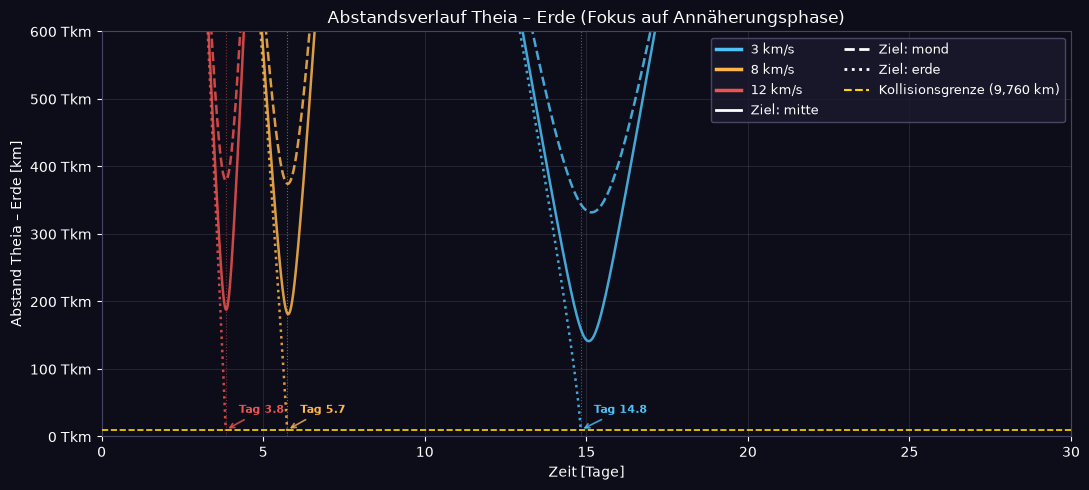

In [17]:
# --- Abstandsdiagramm: Theia <-> Erde für alle 9 Szenarien ---
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

KOLLISIONS_RADIUS_KM = (6371 + 3389)   # Erde + Theia in km

farben = {3: "#4fc3f7", 8: "#ffb74d", 12: "#ef5350"}
stile  = {"mitte": "-", "mond": "--", "erde": ":"}

fig, ax = plt.subplots(figsize=(11, 5), facecolor="#0d0d1a")
ax.set_facecolor("#0d0d1a")

for v in speeds:
    for t in targets:
        tage, dist_km = _abstand_verlauf(sims[(v, t)], "Erde", "Theia")
        if tage.size == 0:
            continue
        
        # Linienstärke leicht erhöht (1.8), damit die Strichmuster beim Zoom besser wirken
        ax.plot(tage, dist_km, color=farben[v], ls=stile[t], lw=1.8, alpha=0.85)

        res = next(r for r in ergebnisse if r["speed_kms"] == v and r["target"] == t)
        if res["kollisions_tag"] is not None:
            kt = res["kollisions_tag"]
            ax.axvline(kt, color=farben[v], ls=":", lw=0.8, alpha=0.5)
            
            # Der Text schwebt nun konstant 35.000 km über der Nulllinie, leicht nach rechts versetzt
            ax.annotate(f"Tag {kt:.1f}", xy=(kt, KOLLISIONS_RADIUS_KM),
                        xytext=(kt + 0.4, 35_000),
                        color=farben[v], fontsize=8, fontweight="bold",
                        arrowprops=dict(arrowstyle="->", color=farben[v], lw=1.2, alpha=0.8))

ax.axhline(KOLLISIONS_RADIUS_KM, color="gold", lw=1.2, ls="--", zorder=5)

ax.set_xlabel("Zeit [Tage]", color="white", fontsize=10)
ax.set_ylabel("Abstand Theia – Erde [km]", color="white", fontsize=10)
ax.set_title("Abstandsverlauf Theia – Erde (Fokus auf Annäherungsphase)", color="white", fontsize=12)

ax.set_xlim(0, 30)

# DER ZOOM: Wir betrachten nur noch die relevantesten 600.000 km (ca. 1.5x Monddistanz)
ax.set_ylim(0, 600_000) 

ax.tick_params(colors="white")
for sp in ax.spines.values():
    sp.set_edgecolor("#444466")
    
ax.grid(True, color="white", alpha=0.1) # Grid minimal sichtbarer gemacht
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:,.0f} Tkm"))

legend_handles = (
    [mlines.Line2D([], [], color=farben[v], lw=2.5, label=f"{v} km/s") for v in speeds] +
    [mlines.Line2D([], [], color="white", ls=stile[t], lw=2.0, label=f"Ziel: {t}") for t in targets] +
    [mlines.Line2D([], [], color="gold", ls="--", lw=1.5, label=f"Kollisionsgrenze ({KOLLISIONS_RADIUS_KM:,} km)")]
)
ax.legend(handles=legend_handles, fontsize=9, facecolor="#1a1a2e",
          edgecolor="#555577", labelcolor="white", loc="upper right", ncol=2)

plt.tight_layout()
plt.show()

### Beobachtungen

Die Tabelle oben fasst alle neun Konfigurationen zusammen: pro Fall, ob (und mit welchem Körper) Theia verschmolzen ist, an welchem Tag dies geschah, sowie den kleinsten Abstand, den Theia jeweils zur Erde und zum Mond erreicht hat. Das Abstandsdiagramm zeigt ergänzend den zeitlichen Verlauf des Erde-Theia-Abstands für alle neun Läufe.

**Zentrale Beobachtungen (für das Raster 3 / 8 / 12 km/s):**

- **Richtung „Erde":** In allen drei Geschwindigkeiten kollidiert Theia mit der Erde. Da der Geschwindigkeitsvektor direkt auf die Erde zeigt und die Gravitation entlang derselben Achse wirkt, gibt es keinen seitlichen Ablenkungseffekt – Theia wird nur zusätzlich beschleunigt und trifft unausweichlich. Die Flugzeit bis zum Einschlag sinkt mit steigender Geschwindigkeit deutlich (von ~14,8 Tagen bei 3 km/s auf ~3,8 Tage bei 12 km/s).

- **Richtung „Mond" und „Mitte":** Hier fliegt Theia am System vorbei und wird gravitativ abgelenkt (Flyby). Der minimale Erdabstand liegt durchweg im Bereich von ~140.000 bis ~380.000 km – weit über der Kollisionsgrenze. Dem Mond kommt Theia in einzelnen Fällen aber deutlich näher (bis ~50.000 km bei 8 km/s Richtung Mitte), wie die Spalte „Min-Abst. Mond" in der Tabelle zeigt.

- **Einfluss der Geschwindigkeit:** Eine höhere Geschwindigkeit verkürzt die Flugzeit und lässt der Gravitation weniger Zeit, die Bahn zu krümmen. Beim direkten Erd-Anflug ändert das nichts am Ergebnis (Treffer bleibt Treffer), beschleunigt aber den Einschlag. Bei den seitlichen Anflügen bleibt der Vorbeiflug erhalten.

<div class="satz"><h3>Antwort auf die Leitfrage</h3>
Ja, es gibt kollisionsfreie Konfigurationen. Entscheidend ist die <b>Zielrichtung</b>, nicht die Geschwindigkeit: Zielt Theia direkt auf die <b>Erde</b>, kommt es bei allen drei getesteten Geschwindigkeiten zur Kollision. Zielt sie dagegen auf den <b>Mond</b> oder die <b>Mitte</b>, fliegt sie in allen drei Geschwindigkeiten am System vorbei. Die Geschwindigkeit verändert nur die Flugzeit und die Bahnkrümmung, nicht aber das grundsätzliche „Treffer-oder-Vorbeiflug"-Ergebnis.
</div>

In [ ]:
# --- Repräsentativer KOLLISIONS-Fall (erster Treffer aus der Matrix) ---

# View Setting
view = 'top'
# view = 'side'
# view = 'standard'

kollisions_faelle = [r for r in ergebnisse if r["kollision_mit"] is not None]
if kollisions_faelle:
    r = kollisions_faelle[0]
    print(f"KOLLISION: {r['speed_kms']} km/s Richtung '{r['target']}' -> Theia trifft {r['kollision_mit']}")
    sel_sim = sims[(r["speed_kms"], r["target"])]
    anim_kollision = Visualizer(sel_sim).animate_3d(view=view, performance_mode=True, dynamic_scaling=True)
    anim_kollision_static = Visualizer(sel_sim).animate_3d(view=view, performance_mode=True, dynamic_scaling=False)
else:
    print("In keiner der neun Konfigurationen kam es zu einer Kollision.")
    anim_kollision = None
    anim_kollision_static = None

display(anim_kollision)
display(anim_kollision_static)

In [ ]:
# View Setting
# view = 'top'
# view = 'side'
view = 'standard'

# --- Repräsentativer KOLLISIONSFREIER Fall (erster Vorbeiflug aus der Matrix), falls vorhanden ---
# dynamic_scaling=True: mitlaufender Zoom, damit der Vorbeiflug an Erde/Mond gut erkennbar ist.
freie_faelle = [r for r in ergebnisse if r["kollision_mit"] is None]
if freie_faelle:
    r = freie_faelle[0]
    print(f"KEINE Kollision: {r['speed_kms']} km/s Richtung '{r['target']}' "
          f"(min. Abstand zur Erde {r['min_abstand_erde']:.3e} m, zum Mond {r['min_abstand_mond']:.3e} m)")
    sel_sim = sims[(r["speed_kms"], r["target"])]
    anim_frei = Visualizer(sel_sim).animate_3d(view=view, performance_mode=True, dynamic_scaling=True)
    anim_frei_static = Visualizer(sel_sim).animate_3d(view=view, performance_mode=True, dynamic_scaling=False)
else:
    print("Jede der neun Konfigurationen führte zu einer Kollision – kein kollisionsfreier Fall vorhanden.")
    anim_frei = None
    anim_frei_static = None

display(anim_frei)
display(anim_frei_static)

<div class="remark"><h3>Bonus: Mond-Crash und Doppel-Crash</h3></div>

**Wie wir diese Kombinationen gefunden haben.** Die Werte sind nicht geraten. Um die schmalen Fenster aufzuspüren, haben wir dieselbe Funktion `run_theia_scenario` in einem **feinen Geschwindigkeits-Sweep** (Schrittweite ca. 0,05–0,1 km/s) über den gesamten Bereich laufen lassen und für jeden Lauf das Feld `kollision_mit` aus dem Ergebnis-Dictionary ausgewertet. So lässt sich genau ablesen, ab welcher Geschwindigkeit das Verhalten umschlägt (Vorbeiflug → Mond-Treffer → Erd-Treffer). Diese systematische Suche – das automatisierte Durchprobieren der vielen Zwischenwerte und das Eingrenzen der Treffer-Bereiche – haben wir mit Unterstützung des KI-Assistenten **Claude** durchgeführt, der den Geschwindigkeitsbereich gezielt durchgegangen ist. Dabei zeigt sich, **wie schmal** diese Fenster tatsächlich sind:

- **Mond-Crash:** Richtung `mond` trifft Theia den Mond praktisch nur in einem **hauchdünnen Fenster um ≈ 2,0 km/s** – bei 0,05 km/s Schrittweite trifft ausschließlich `2,00` km/s, während `1,95` und `2,05` km/s schon vorbeifliegen. Bei dieser Geschwindigkeit erreicht Theia den Mond erst nach ~24 Tagen genau dann, wenn er auf seiner Bahn an der richtigen Stelle steht. Der entstehende Klumpen verlässt anschließend das System (kein Erd-Treffer).
- **Doppel-Crash:** Richtung `erde` werden **beide** Körper nur im schmalen Band **≈ 6,1–6,3 km/s** getroffen. Hier streift Theia auf dem Weg zur Erde zuerst den Mond (~6,7 Tage) und stürzt dann in die Erde (~7,4 Tage). Schon ab ~6,4 km/s ist Theia zu schnell, „überholt" den Mond und fliegt direkt in die Erde – ein reiner Erd-Treffer.

Als repräsentative Werte zeigen wir unten `2,0 km/s` (Mond) und `6,2 km/s` (Doppel).

In [ ]:
# View Setting
view = 'top'
# view = 'side'
# view = 'standard'

# --- MOND-CRASH: Theia trifft gezielt den Mond ---
sim_mond, res_mond = run_theia_scenario(2.0, "mond", total_time=50)
print(f"MOND-CRASH: 2.0 km/s Richtung 'mond' -> Theia trifft: {res_mond['kollision_mit']}")
print(f"(Kleinster Abstand zur Erde: {res_mond['min_abstand_erde']:.3e} m)")

# Gleiche Visualisierungsfunktion wie oben.
anim_mond_crash = Visualizer(sim_mond).animate_3d(view=view, performance_mode=True, dynamic_scaling=True)
anim_mond_crash_static = Visualizer(sim_mond).animate_3d(view=view, performance_mode=True, dynamic_scaling=False)
display(anim_mond_crash)
display(anim_mond_crash_static)

In [ ]:
# View Setting
view = 'top'
# view = 'side'
# view = 'standard'

# --- DOPPEL-CRASH: Theia trifft BEIDE Körper in einem einzigen Anflug ---
# Eigener Lauf bei 6.2 km/s Richtung 'erde'; total_time=20 Tage reicht, da beide
# Einschläge (Mond ~6.7 Tage, Erde ~7.4 Tage) lange davor passieren.
sim_doppel, res_doppel = run_theia_scenario(6.2, "erde", total_time=20)
print(f"DOPPEL-CRASH: 6.2 km/s Richtung 'erde' -> Theia trifft: {res_doppel['kollision_mit']}")

# Gleiche Visualisierungsfunktion wie oben: einmal mit mitlaufendem Zoom (dynamic_scaling=True),
# einmal mit festem Maßstab (dynamic_scaling=False).
anim_doppel_crash = Visualizer(sim_doppel).animate_3d(view=view, performance_mode=True, dynamic_scaling=True)
anim_doppel_crash_static = Visualizer(sim_doppel).animate_3d(view=view, performance_mode=True, dynamic_scaling=False)
display(anim_doppel_crash)
display(anim_doppel_crash_static)

## UnitTests

Zur Verifikation der Korrektheit des Programmentwurfs wurde eine automatisierte Testsuite basierend auf dem Python-Framework unittest implementiert. Diese stellt sicher, dass Modifikationen am System keine mathematischen Regressionen verursachen.

In [ ]:
import unittest

class TestBody(unittest.TestCase):
    """
    Unittests für den Body-Datentyp
    """ 

    def setUp(self):
        #Variablen initialisieren
        self.body_a = Body("Erde", [0, 0, 0], [0, 0, 0], radius=100.0, mass=50.0, color="blue")
        self.body_b = Body("Mond", [300, 0, 0], [0, 20, 0], radius=20.0, mass=5.0, color="gray")
        
    def test_01_init(self):
        #Testen, ob init-Methode fehlerfrei funktioniert
        self.assertEqual(self.body_a.name, "Erde")
        np.testing.assert_array_equal(self.body_b.position, np.array([300, 0, 0], dtype=float))
        self.assertIsInstance(self.body_b.velocity, np.ndarray)
        
    def test_02_distance(self):
        # Testen, ob Distanz-Funktion fehlerfrei funktioniert
        distance = self.body_a.get_distance_to_body(self.body_b)
        #Selbst errechneter Abstand = 300.0
        self.assertEqual(distance, 300.0)
        self.assertIsInstance(distance, float)
        
    def test_03_changePosition(self):
        # Testen, ob update_position Funktion fehlerfrei funktioniert
        self.body_b.update_position(10.0)
        #Abgleichen mit selbst errechnetem Ergebnis
        np.testing.assert_array_equal(self.body_b.position, np.array([300, 200, 0], dtype=float))
        
    def test_04_changeVelocricity(self):
        # Testen, ob update_velocity Funktion fehlerfrei funktioniert
        acceleration = np.array([5,0,0], dtype=float)
        self.body_b.update_velocity(acceleration,10.0)
        #Selbst errechnetes Ergebnis
        expectedVelocricity = np.array([50,20,0], dtype=float)
        np.testing.assert_array_equal(self.body_b.velocity, expectedVelocricity)
        
    def test_05_getMomentum(self):
        # Testen, ob get_momentum Funktion fehlerfrei Funktioniert
        #Selbst errechnetes Ergebnis
        expectedMomentum = np.array([0,100,0], dtype=float)
        np.testing.assert_array_equal(expectedMomentum, self.body_b.get_momentum())     

In [ ]:

class TestSimulation(unittest.TestCase):
    """
    Unittests für die Simulation
    """ 
    def setUp(self):
        self.body_1 = Body("Körper1", [0, 0, 0], [0, 0, 0], radius=10.0, mass=100, color="red")
        self.body_2 = Body("Körper2", [100, 0, 0], [0, 0, 0], radius=5.0, mass=10.0, color="green")
        
        self.simulation = Simulation(10.0)
        
    def test_01_addAndRemoveBody(self):
        #Testen, ob ein Körper erfolgreich entfernt bzw. hinzugefügt wird
        self.simulation.add_body(self.body_1)
        self.assertEqual(len(self.simulation.bodies), 1)
        
        self.simulation.remove_body(self.body_1)
        self.assertEqual(len(self.simulation.bodies), 0)
        
    def test_02_calculate_gravity(self):
        #Testen, ob die Anziehungskräfte auch richtig berechnet werden, wenn die Körper sich am selben Punkt befinden
        self.simulation.add_body(self.body_1)
        body_3 = Body("Körper12", [0, 0, 0], [0, 0, 0], radius=10.0, mass=100, color="red")
        self.simulation.add_body(body_3)
        
        forces = self.simulation.calculate_gravity()
        
        #wenn es der gleiche Ort ist, darf es keine Anziehungskraft geben
        expectedForce = np.array([ 0.0,  0.0,  0.0], dtype=float)
        
        np.testing.assert_array_almost_equal(forces[self.body_1.name], expectedForce, decimal=6)
        np.testing.assert_array_almost_equal(forces[body_3.name], expectedForce, decimal=6)
        
    def test_03_checkCollisions_true(self):
        #Testen, ob die Funktion Kollisionen erkennt und richtig verarbeitet
        self.simulation.add_body(self.body_1)
        self.simulation.add_body(self.body_2)
        
        # Position so anpassen, dass die Körper kollidieren
        self.body_2.position = np.array([12,0,0], dtype=float)
        
        collision = self.simulation.check_collisions()
        self.assertTrue(collision)
        self.assertEqual(len(self.simulation.bodies), 1)
    
    def test_04_checkCollisions_false(self):
        #Testen, ob die Funktion nicht kollidierende Körper erkennt und richtig verarbeitet
        self.simulation.add_body(self.body_1)
        self.simulation.add_body(self.body_2)
        
        #Position so anpassen, dass die Körper nicht kollidieren
        self.body_2.position = np.array([200,0,0], dtype=float)
        
        collision = self.simulation.check_collisions()
        self.assertFalse(collision)
        self.assertEqual(len(self.simulation.bodies), 2)
        
    def test_05_blendColors(self):
        #Testen, ob die Farben richtig gemischt werden
        color = self.simulation._blend_colors('blue', 'red')
        #selbst errechnetes Ergebnis
        violett = (0.5, 0.0, 0.5)
        self.assertEqual(color,violett)
        
    def test_06_MergeBodies(self):
        #Testen, ob die Masse und der Radius des verschmolzenen Körpers richtig ausgerechnet und eingetragen werden
        self.simulation.add_body(self.body_1)
        self.simulation.add_body(self.body_2)
        
        self.body_2.position = np.array([12,0,0], dtype=float)
        
        self.simulation.merge_bodies(self.body_1, self.body_2)
        
        #weil mass1 + mass2 =110
        self.assertEqual(self.simulation.bodies[0].mass, 110)
        
        expected_radius = (10.0**3 + 5.0**3)**(1/3)
        self.assertAlmostEqual(self.simulation.bodies[0].radius, expected_radius) 
        
    def test_07_step(self):
        # Testen, ob die step-Funktion die Historie richtig aufzeichnet
        self.simulation.add_body(self.body_1)
        
        self.assertEqual(self.simulation.recorded_steps, 0)   
        self.assertEqual(len(self.simulation.history["Körper1"]), 0) 
        
        self.simulation.step()
        
        self.assertEqual(self.simulation.recorded_steps, 1)   
        self.assertEqual(len(self.simulation.history["Körper1"]), 1)  
        
    def test_08_run(self):
        #Testen, ob die richtige Anzahl an steps mit Ausführung der run-Funktion ausgeführt werden
        # und richtig aufgezeichnet werden
        self.simulation.add_body(self.body_1)
        
        self.assertEqual(self.simulation.recorded_steps, 0)   
        self.assertEqual(len(self.simulation.history["Körper1"]), 0) 
        
        self.simulation.run(30.0) #3*10 (aus der Simulation)
        
        self.assertEqual(self.simulation.recorded_steps, 3)   
        self.assertEqual(len(self.simulation.history["Körper1"]), 3)

In [ ]:
class TestVisualizer(unittest.TestCase):
    """
    Unittests für den Visualizer
    """ 

    def setUp(self):
        #Variablen initialisieren
        self.body_1 = Body("Körper1", [0, 0, 0], [0, 0, 0], radius=10.0, mass=100, color="red")
        self.body_2 = Body("Körper2", [100, 0, 0], [0, 0, 0], radius=5.0, mass=10.0, color="green")
        
        self.simulation = Simulation(1.0)
        self.visualizer = Visualizer(self.simulation,1.0)
    
    def test_01_HTMLTest(self):
        #Testen, ob der richtige Datentyp ausgegeben wird
        self.simulation.add_body(self.body_1)
        self.simulation.add_body(self.body_2)
        
        self.simulation.step()
        self.simulation.step()
        self.simulation.step()
        
        result = self.visualizer.animate_3d();
        self.assertIsInstance(result, HTML)   
        
    def test_02_EingabeValidierung(self):
        #Testen, ob der Funktion einen Error wirft, wenn keine Simulation angegeben wird
        visualizer2 = Visualizer(None, 1);
        
        with self.assertRaises(ValueError):
            visualizer2.animate_3d(None)

In [ ]:
class TestScenarioController(unittest.TestCase):
    """
    Unittests für den ScenarioController
    """ 
    def setUp(self):
        self.body_1 = Body("erde", [0, 0, 0], [0, 0, 0], radius=10.0, mass=100, color="red")
        self.body_2 = Body("mond", [100, 0, 0], [0, 0, 0], radius=5.0, mass=10.0, color="green")
        
        self.simulation = Simulation(10.0)
        
        self.scenarioController = ScenarioController(10.0, "erde")
        
    def test_01_calculateGeometry(self):
        # Testen, ob die richige Position von Theia ausgegeben wird
        self.simulation.add_body(self.body_1)
        self.simulation.add_body(self.body_2)
        thea_pos = self.scenarioController.calculate_geometry(self.simulation)
        
        #Vergleich mit selbst errechnetem Ergebnis
        np.testing.assert_array_equal(thea_pos, np.array([50.0, 4e9, 0.0]))
      
    def test_02_calculate_velocity_vectorErde(self):
        #Testen, ob der richtige Geschwindigkeitsvektor der Erde ausgerechnet wird
        self.simulation.add_body(self.body_1)
        self.simulation.add_body(self.body_2)
        
        velocity_vector = self.scenarioController.calculate_velocity_vector(np.array([50.0, 4e9, 0.0]), "erde", self.simulation)
        
        #Vergleich mit selbst errechnetem Ergebnis
        np.testing.assert_array_almost_equal(velocity_vector, np.array([-1.25e-07, -10.0, 0.0]), 6)  
        
    def test_02_calculate_velocity_vectorMond(self):
        #Testen, ob der richtige Geschwindigkeitsvektor des Mondes ausgerechnet wird
        self.simulation.add_body(self.body_1)
        self.simulation.add_body(self.body_2)
        velocity_vector = self.scenarioController.calculate_velocity_vector(np.array([50.0, 4e9, 0.0]), "mond", self.simulation)
        
        #Vergleich mit selbst errechnetem Ergebnis
        np.testing.assert_array_almost_equal(velocity_vector, np.array([1.25e-07, -10.0, 0.0]), 6)
        
    def test_02_calculate_velocity_vectorMitte(self):
        #Testen, ob der richtige Geschwindigkeitsvektor der Mitte ausgerechnet wird
        self.simulation.add_body(self.body_1)
        self.simulation.add_body(self.body_2)
        velocity_vector = self.scenarioController.calculate_velocity_vector(np.array([50.0, 4e9, 0.0]), "mitte", self.simulation)
        
        #Vergleich mit selbst errechnetem Ergebnis
        np.testing.assert_array_almost_equal(velocity_vector, np.array([0.0, -10.0, 0.0]))
    
    def test_03_setup_theia(self):
        #Testen, ob die Theia richtig initialisiert wurd
        self.simulation.add_body(self.body_1)
        self.simulation.add_body(self.body_2)
        
        anzahlVorher = len(self.simulation.bodies)
        
        self.scenarioController.setup_theia(self.simulation)
        
        # Test ob Körper hinzugefügt wurde
        self.assertEqual(len(self.simulation.bodies), anzahlVorher + 1)
        
        # Test ob neuer Körper Theia ist
        theia = self.simulation.bodies[-1]
        self.assertEqual(theia.name, "Theia")
        
        # Errechnete Werte abgleichen
        self.assertEqual(theia.radius, 3389000.0)
        self.assertEqual(theia.mass, 6.39e23)
        self.assertEqual(theia.color, "red")

In [ ]:
class TheiaScenarien(unittest.TestCase):
    """
    Unittests für die Theia Scenarien
    """ 
    def setUp(self):
        # Initialisierung der Variablen
        self.simulation = baue_erde_mond_sim(1.0)
    
    def test_01_Aufbau(self):
        #Testen, ob die Funktion baue_erde_mond_sim(1.0) 2 Bodies hinzufügt
        # (Aufruf Funktion in setup)
        self.assertEqual(len(self.simulation.bodies), 2)
        
    def test_02_AbstandVerlauf(self):
        #Testen, ob die Tage und der Abstand richtig aufgezeichnet werden
        time_step = 86400.0  # 1 Tag in Sekunden

        sim = baue_erde_mond_sim(time_step)
        #Daten in History schreiben
        sim.history = {
            "Erde": np.array([[0.0, 0.0, 0.0]]),
            "Mond": np.array([[384400000.0, 0.0, 0.0]])
        }

        tage, abstaende = _abstand_verlauf(sim, "Erde", "Mond")
        
        # es muss mindestens ein Wert vorhanden sein
        self.assertTrue(len(tage) > 0)
        self.assertTrue(len(abstaende) > 0)
        
        # Der Startabstand ist 384.400.000 Meter -> 384.400 km
        self.assertAlmostEqual(abstaende[0], 384400.0, places=1)
        
        # Erster Eintrag ist vor Start
        self.assertEqual(tage[0], 0.0)
        
    def test_03_findeKörper(self):
        #Test, ob richtiger Körper zurückgegeben wurde
        body = finde_koerper(self.simulation, 'Mond')
        self.assertEqual(body.name, 'Mond')
        
    def test_04_keineKollision(self):
        #Testen, ob bei kurzer Laufzeiht ohne Kollision Werte genullt sind 
        # Extrem kurze Laufzeit(0.002 Tage = 1 Schritt), es kann zu keiner Kollision führen
        simulation, result = run_theia_scenario(speed_kms=3, target="mitte", total_time=0.002, time_step=0.002)
        
        self.assertIsNone(result["kollision_mit"])
        self.assertIsNone(result["kollisions_tag"])

In [ ]:
if __name__ == '__main__':
    #Durchführung der Tests
    loader = unittest.TestLoader()
    suite = unittest.TestSuite()

    #Initialisierung der BodyTests
    suite.addTests(loader.loadTestsFromTestCase(TestBody))
    suite.addTests(loader.loadTestsFromTestCase(TestSimulation))
    suite.addTests(loader.loadTestsFromTestCase(TestVisualizer))
    suite.addTests(loader.loadTestsFromTestCase(TestScenarioController))
    suite.addTests(loader.loadTestsFromTestCase(TheiaScenarien))
    
    #Der Rest wird visuell geprüft!
    
    runner = unittest.TextTestRunner()

    runner.run(suite)

## Quellen
- [1] https://physikbuch.schule/newtons-law-of-universal-gravitation.html
- [2] https://www.scinexx.de/news/kosmos/3-body-problem-doch-nicht-rein-chaotisch/
- [3] https://www.leifiphysik.de/mechanik/impulserhaltung-und-stoesse/grundwissen/impuls-und-impulserhaltungssatz
- [4] https://www.leifiphysik.de/mechanik/kraft-und-bewegungsaenderung/grundwissen/2-newtonsches-gesetz-aktionsprinzip
- [5] https://www.leifiphysik.de/mechanik/lineare-bewegung-gleichungen/grundwissen/gleichmaessig-beschleunigte-bewegungen
- [6] https://www.leifiphysik.de/mechanik/masse-volumen-und-dichte/grundwissen/festlegung-der-dichte
- [7] https://itp.uni-frankfurt.de/~luedde/Lecture/Mechanik/Intranet/Skript/Kap4/node2.html
- [8] https://www.hms-dtzb.de/unterricht/sonnensystem_info_18_19/seiten/mars.html
- [9] https://www.tat.physik.uni-tuebingen.de/~schaefer/teach/f/cp.pdf
- [10] https://blog.roboflow.com/keep-objects-centered-with-object-detection-based-camera-framing/